<a href="https://colab.research.google.com/github/SAM126599/Data-Analysis-of-Hotel-Booking/blob/main/Sales_Forecasting_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
file_path = "Project1.csv.csv"                                     # keep CSV in same folder
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/ALL IZZZ WELLL..../Projects.../Project1.csv.csv")

print("✅ CSV DATA LOADED SUCCESSFULLY")
print(df.head())


✅ CSV DATA LOADED SUCCESSFULLY
         date  product_id product_name     category region sales_channel  \
0  2023-01-01        1007   Smartwatch  Electronics   East       Offline   
1  2023-01-02        1004   Headphones  Electronics  North        Online   
2  2023-01-03        1008   Headphones  Accessories  North       Offline   
3  2023-01-04        1005   Headphones  Electronics  South       Offline   
4  2023-01-05        1007   Smartphone  Accessories  South       Offline   

   units_sold  unit_price  promotion_flag  discount_percentage   season  \
0          77       59492               0                    5  Monsoon   
1          57       55002               0                   15  Festive   
2          13       74355               1                   15  Festive   
3          78       26762               1                   10  Monsoon   
4          56       13046               0                   10  Monsoon   

   holiday_flag  revenue  
0             0  4580884  
1      

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ALL IZZZ WELLL..../Projects.../Project1.csv.csv')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,product_id,product_name,category,region,sales_channel,units_sold,unit_price,promotion_flag,discount_percentage,season,holiday_flag,revenue
0,2023-01-01,1007,Smartwatch,Electronics,East,Offline,77,59492,0,5,Monsoon,0,4580884
1,2023-01-02,1004,Headphones,Electronics,North,Online,57,55002,0,15,Festive,1,3135114
2,2023-01-03,1008,Headphones,Accessories,North,Offline,13,74355,1,15,Festive,1,966615
3,2023-01-04,1005,Headphones,Electronics,South,Offline,78,26762,1,10,Monsoon,0,2087436
4,2023-01-05,1007,Smartphone,Accessories,South,Offline,56,13046,0,10,Monsoon,1,730576


In [20]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

In [21]:
print("\n📊 DATA SUMMARY")
print(df.describe())

# Feature extraction
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year



📊 DATA SUMMARY
                      date   product_id  units_sold    unit_price  \
count                  260   260.000000  260.000000    260.000000   
mean   2023-05-10 12:00:00  1005.023077   61.530769  41663.788462   
min    2023-01-01 00:00:00  1001.000000    5.000000   2060.000000   
25%    2023-03-06 18:00:00  1003.000000   33.000000  25010.750000   
50%    2023-05-10 12:00:00  1005.000000   59.000000  39772.500000   
75%    2023-07-14 06:00:00  1007.000000   91.000000  59223.500000   
max    2023-09-17 00:00:00  1009.000000  119.000000  79454.000000   
std                    NaN     2.659478   33.161518  21988.793687   

       promotion_flag  discount_percentage  holiday_flag       revenue  
count      260.000000           260.000000    260.000000  2.600000e+02  
mean         0.534615            10.115385      0.526923  2.529589e+06  
min          0.000000             0.000000      0.000000  1.875000e+04  
25%          0.000000             5.000000      0.000000  8.930985e+05

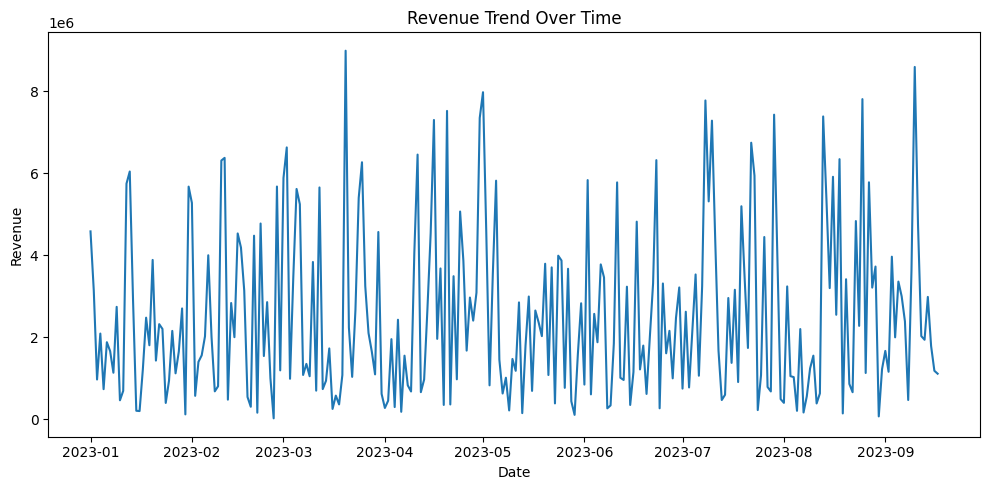

In [22]:

plt.figure(figsize=(10, 5))
sns.lineplot(x='date', y='revenue', data=df)
plt.title("Revenue Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


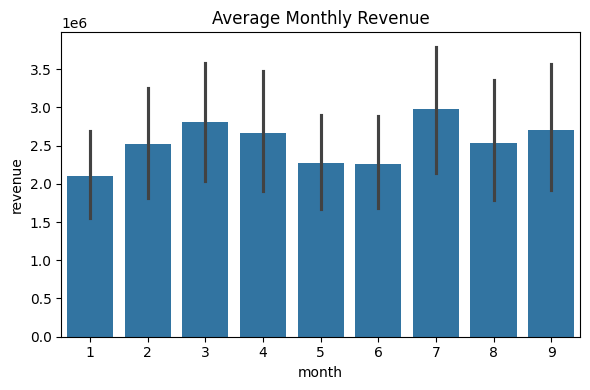

In [23]:


plt.figure(figsize=(6, 4))
sns.barplot(x='month', y='revenue', data=df)
plt.title("Average Monthly Revenue")
plt.tight_layout()
plt.show()

In [24]:

plt.figure(figsize=(6, 4))
print(df.columns)
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

Index(['date', 'product_id', 'product_name', 'category', 'region',
       'sales_channel', 'units_sold', 'unit_price', 'promotion_flag',
       'discount_percentage', 'season', 'holiday_flag', 'revenue', 'month',
       'year'],
      dtype='object')


<Figure size 600x400 with 0 Axes>

In [25]:
print("Cleaned columns:", df.columns)

Cleaned columns: Index(['date', 'product_id', 'product_name', 'category', 'region',
       'sales_channel', 'units_sold', 'unit_price', 'promotion_flag',
       'discount_percentage', 'season', 'holiday_flag', 'revenue', 'month',
       'year'],
      dtype='object')


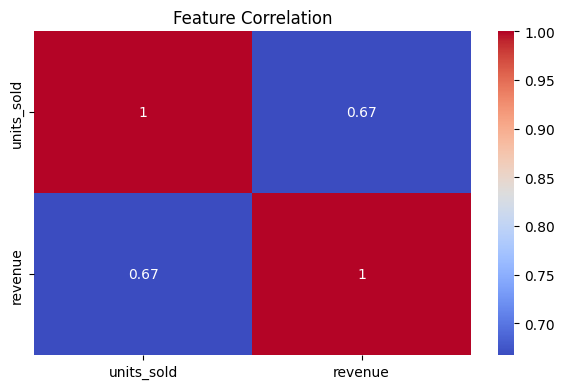

In [26]:
required_cols = ['units_sold', 'price', 'marketing_spend', 'revenue']

available_cols = [col for col in required_cols if col in df.columns]

if len(available_cols) >= 2:
    plt.figure(figsize=(6, 4))
    sns.heatmap(df[available_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Feature Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Not enough numeric columns available for heatmap")
# Removed the problematic line: df = pd.read_csv("Project1.csv.csv") as the df is already loaded correctly earlier.

In [27]:
# Normalize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns after cleaning:", df.columns)

Columns after cleaning: Index(['date', 'product_id', 'product_name', 'category', 'region',
       'sales_channel', 'units_sold', 'unit_price', 'promotion_flag',
       'discount_percentage', 'season', 'holiday_flag', 'revenue', 'month',
       'year'],
      dtype='object')


Columns: Index(['date', 'product_id', 'product_name', 'category', 'region',
       'sales_channel', 'units_sold', 'unit_price', 'promotion_flag',
       'discount_percentage', 'season', 'holiday_flag', 'revenue', 'month',
       'year'],
      dtype='object')


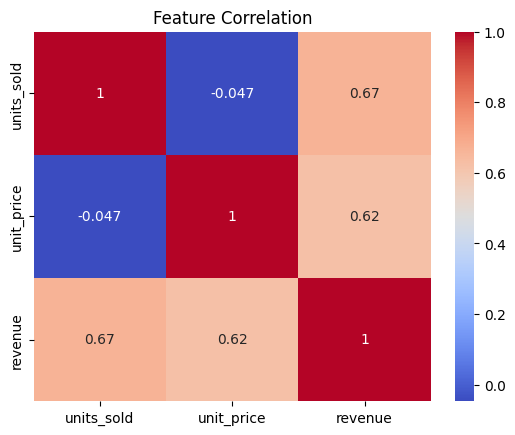

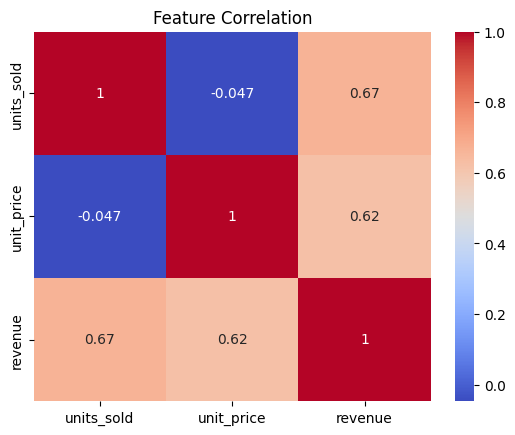

In [28]:
print("Columns:", df.columns)

df['date'] = pd.to_datetime(df['date'], errors='coerce')

cols = ['units_sold', 'unit_price', 'revenue']

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

sns.heatmap(df[['units_sold', 'unit_price', 'revenue']].corr(),annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [29]:

X = df[['units_sold', 'unit_price']]
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📈 MODEL PERFORMANCE")
print(f"Mean Absolute Error  : {mae:.2f}")
print(f"Root Mean Sq. Error  : {rmse:.2f}")


📈 MODEL PERFORMANCE
Mean Absolute Error  : 420703.96
Root Mean Sq. Error  : 558460.66


In [30]:

future_sales = pd.DataFrame({
    "units_sold": [140, 160, 180],
    "unit_price": [320, 350, 380]
})

future_revenue = model.predict(future_sales)

print("\n🔮 FUTURE REVENUE PREDICTIONS")
for i, value in enumerate(future_revenue):
    print(f"Forecast {i+1}: ₹{value:.2f}")


🔮 FUTURE REVENUE PREDICTIONS
Forecast 1: ₹3322595.05
Forecast 2: ₹4184099.84
Forecast 3: ₹5045604.63


In [31]:

df['predicted_revenue'] = model.predict(X)

df.to_csv("sales_forecast_output.csv", index=False)

print("\n💾 Forecasted data saved as 'Project1_output.csv'")


💾 Forecasted data saved as 'Project1_output.csv'


In [32]:
!pip install reportlab pandas
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch

# Predict revenue
df['predicted_revenue'] = model.predict(X)

# Save CSV (as you already do)
df.to_csv("sales_forecast_output.csv", index=False)

# Create PDF
pdf_file_name = "Sales_Forecast_Report.pdf"
c = canvas.Canvas(pdf_file_name, pagesize=A4)

width, height = A4
x_margin = 40
y_position = height - 40
line_height = 14

c.setFont("Helvetica", 10)

# Title
c.setFont("Helvetica-Bold", 12)
c.drawString(x_margin, y_position, "Sales Forecast Report")
y_position -= 20

c.setFont("Helvetica", 10)
c.drawString(x_margin, y_position, "=" * 60)
y_position -= 20

# Convert DataFrame to text
table_text = df.to_string(index=False).split("\n")

# Write table line by line with page breaks
for line in table_text:
    if y_position < 50:
        c.showPage()
        c.setFont("Helvetica", 10)
        y_position = height - 40

    c.drawString(x_margin, y_position, line)
    y_position -= line_height

# Save PDF
c.save()

print("💾 Forecasted data saved as 'sales_forecast_output.csv'")
print("📄 Forecast report saved as 'Sales_Forecast_Report.pdf'")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.9 MB/s eta 0:00:00
💾 Forecasted data saved as 'sales_forecast_output.csv'
📄 Forecast report saved as 'Sales_Forecast_Report.pdf'
